# Inverse Modeling: Physics-based vs. Data-driven

Recover **Young's Modulus ($E$)** and **Poisson's ratio ($\nu$)** of a cantilever beam from 40 sensor measurements (20 displacements $y_q$ + 20 axial strains $\epsilon_{xx}$). True values: $E = 65{,}000$ Pa, $\nu = 0.29$.

| Method | Strategy | Key property |
|---|---|---|
| **JAX-FEM Gradient** | Physics-based | Exact gradients via adjoint AD; no training data needed |
| **CRPS** | Data-driven | Stochastic network, energy score objective; gives posterior ensemble |
| **MDN** | Data-driven | Gaussian mixture, maximum likelihood; gives full $p(q\mid y)$ |

In [36]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import pandas as pd
import uncertain_variables as uv
import digital_twinning as dt
import matplotlib.pyplot as plt
import torch
import logging
import basix
import seaborn as sns


from jax_fem.problem import Problem
from jax_fem.solver import ad_wrapper
from jax_fem.generate_mesh import box_mesh, Mesh, get_meshio_cell_type
from jax_fem.basis import get_elements

import sys, os
sys.path.append(os.path.abspath('..'))
from inverse_modeling import CRPSModel, MDNModel, JaxFemGradientModel
from inverse_modeling.calibration import gradient_based_model_calibration

logging.getLogger("jax_fem").setLevel(logging.WARNING)

In [18]:
def plot_matrix_scatter(prior, posterior):
    df_prior = pd.DataFrame(prior, columns=['E', 'nu']); df_prior['Distribution'] = 'Prior'
    df_post = pd.DataFrame(posterior, columns=['E', 'nu']); df_post['Distribution'] = 'Posterior'
    df_all = pd.concat([df_prior, df_post], ignore_index=True)

    palette = {'Prior': 'gray', 'Posterior': 'seagreen'}
    g = sns.pairplot(
        df_all, hue='Distribution', vars=['E', 'nu'],
        plot_kws=dict(alpha=0.4, s=10),
        diag_kws=dict(fill=True, alpha=0.4),
        palette=palette,
        diag_kind='kde', kind='scatter',
        corner=False
    )

    # Mark true values
    for ax in g.axes.flat:
        if ax is None:
            continue
        xlabel, ylabel = ax.get_xlabel(), ax.get_ylabel()
        true_vals = {'E': E_true, 'nu': nu_true}
        if xlabel in true_vals:
            ax.axvline(true_vals[xlabel], color='red', linestyle='--', linewidth=1.2)
        if ylabel in true_vals:
            ax.axhline(true_vals[ylabel], color='red', linestyle='--', linewidth=1.2)

    g.figure.suptitle('Prior vs Posterior — Pair Plot  (red dashed = true value)', y=1.02, fontweight='bold')
    plt.show()

## 1. Physics Setup

Isotropic linear elasticity on a $5 \times 1 \times 1$ m beam. Clamped at $x=0$, 100 N downward traction at $x=5$.

In [19]:
class CantileverElasticity(Problem):
    def get_tensor_map(self):
        def stress(u_grad, E, nu):
            mu  = E / (2.0 * (1.0 + nu))
            lam = (E * nu) / ((1.0 + nu) * (1.0 - 2.0 * nu))
            eps = 0.5 * (u_grad + u_grad.T)
            return lam * jnp.trace(eps) * jnp.eye(self.dim) + 2.0 * mu * eps
        return stress

    # The force is applied at the right boundary in the z-direction, so the surface map returns a function that takes the displacement and coordinates as input and returns a force vector with a non-zero component in the z-direction. The force is set to 100.0 for demonstration purposes.
    def get_surface_maps(self):
        return [lambda u, x: jnp.array([0.0, 0.0, 100.0])]

    def set_params(self, params):
        self.internal_vars = params

def left_boundary(x):  return jnp.isclose(x[0], 0.0)
def right_boundary(x): return jnp.isclose(x[0], 5.0)

def get_basis_func_grads(problem):
    fe = problem.fes[0]
    # Get the element family, element type, and degree and the reordering of the gradient components for the given finite element type. The reordering is necessary because basix returns the gradients in a different order than the physical coordinates.
    element_family, basix_ele, _, _, degree, re_order = get_elements(fe.ele_type)
    element       = basix.create_element(element_family, basix_ele, degree)
    node_points   = element.points
    # The shape function gradients are returned in the order of (dN/dxi, dN/deta, dN/dzeta) for each node. We need to reorder them to (dN/dzeta, dN/dxi, dN/deta) to match the order of physical coordinates (x, y, z).
    # 1st param of tabulate is the derivative order (1 for first derivatives), 2nd param is the points at which to evaluate the shape functions and their gradients, 3rd param is the reordering of the gradient components, and 4th param is for higher-order derivatives (not used here).
    # We call it vals_and_grads because the first slice (index 0) contains the shape function values and the subsequent slices (index 1, 2, 3) contain the gradients with respect to xi, eta, zeta respectively.
    # re_order is used to reorder the gradient components from (dN/dxi, dN/deta, dN/dzeta) to (dN/dzeta, dN/dxi, dN/deta) to match the order of physical coordinates (x, y, z).
    vals_and_grads = element.tabulate(1, node_points)[:, :, re_order, :]
    # The shape function gradients are now in the order of (dN/dzeta, dN/dxi, dN/deta) for each node. We need to reorder them back to (dN/dxi, dN/deta, dN/dzeta) to match the order of physical coordinates (x, y, z) for the Jacobian computation.
    shape_grads_ref = jnp.transpose(vals_and_grads[1:, :, :, 0], axes=(1, 2, 0))
    physical_coos   = fe.points[fe.cells]
    jac = jnp.sum(physical_coos[:, None, :, :, None] * shape_grads_ref[None, :, :, None, :], axis=2, keepdims=True)
    return (shape_grads_ref[None, :, :, None, :] @ jnp.linalg.inv(jac))[:, :, :, 0, :]

## 2. Mesh, Sensors & Training Data

$20 \times 2 \times 2$ HEX8 mesh. 20 sensor nodes randomly selected from non-clamped interior nodes. Training set: 100 FEM simulations with $(E, \nu)$ drawn from a uniform prior.

In [20]:
Nx, Ny, Nz = 20, 2, 2
raw_mesh = box_mesh(Nx=Nx, Ny=Ny, Nz=Nz, domain_x=5.0, domain_y=1.0, domain_z=1.0)
# HEX8 is the cell type for hexahedral elements with 8 nodes, which is commonly used in 3D finite element analysis. The mesh.cells_dict[get_meshio_cell_type('HEX8')] retrieves the connectivity information for the HEX8 elements from the mesh.
ele_type = 'HEX8'
#ele_type = 'TET10'
mesh     = Mesh(raw_mesh.points, raw_mesh.cells_dict[get_meshio_cell_type(ele_type)])
# location_fns specifies the locations where the force is applied.
problem  = CantileverElasticity(mesh, vec=3, dim=3, ele_type=ele_type,
    dirichlet_bc_info=[[left_boundary]*3, [0,1,2], [lambda x: 0.]*3],
    location_fns=[right_boundary])
fwd_pred         = ad_wrapper(problem)
shape_grads_phys = get_basis_func_grads(problem)

def get_node_idx(i, j, k): return i * (Ny + 1) * (Nz + 1) + j * (Nz + 1) + k
# 20 random sensor nodes
np.random.seed(42)
sensor_node_indices = np.random.choice(
    [get_node_idx(i, j, k) for i in range(Nx+1) for j in range(Ny+1) for k in [0]],
    20, replace=False)

# we need node_to_cell_map to compute the strain at the sensor nodes, which requires the gradients of the shape functions in the physical coordinates. The shape function gradients are computed at the cell level, so we need to map each sensor node to its corresponding cell and local node index within that cell to extract the correct shape function gradients for computing the strain at the sensor nodes.
node_to_cell_map = {}
for c, cell in enumerate(mesh.cells):
    for l, g in enumerate(cell):
        if int(g) in sensor_node_indices and int(g) not in node_to_cell_map:
            node_to_cell_map[int(g)] = (c, l)

# Run FEM and return the QoI vector, which consists of the vertical displacements (y_q) and the normal strains in the x-direction (eps_xx) at the sensor nodes.
def run_fem(E, nu):
    u    = fwd_pred([jnp.full((mesh.cells.shape[0], 8), E), jnp.full((mesh.cells.shape[0], 8), nu)])[0]
    y_q  = u[sensor_node_indices, 1]
    eps_xx = [
        jnp.sum(u[mesh.cells[node_to_cell_map[int(g)][0]], :, None] *
                shape_grads_phys[node_to_cell_map[int(g)][0], node_to_cell_map[int(g)][1], :, None, :],
                axis=0)[0, 0]
        for g in sensor_node_indices
    ]
    return jnp.concatenate([y_q, jnp.stack(eps_xx)])

# Plot Sensor Locations, Original and Deformed Shape

In [21]:
import plotly.graph_objects as go

# Representative deformed config using mean training parameters
E_rep = float(65000.0)  # Pa
nu_rep = float(0.3)  # Example value, replace with actual mean if available
u_rep = fwd_pred([jnp.full((mesh.cells.shape[0], 8), E_rep),
                  jnp.full((mesh.cells.shape[0], 8), nu_rep)])[0]
points_def = mesh.points + np.array(u_rep)
disp_mag = np.linalg.norm(np.array(u_rep), axis=1)
sensor_def = points_def[sensor_node_indices]

fig = go.Figure()

# Undeformed mesh (background reference)
fig.add_trace(go.Scatter3d(
    x=mesh.points[:, 0], y=mesh.points[:, 1], z=mesh.points[:, 2],
    mode='markers',
    marker=dict(size=2, color='lightgray', opacity=0.35),
    name='Undeformed'
))

# Deformed nodes coloured by displacement magnitude
fig.add_trace(go.Scatter3d(
    x=points_def[:, 0], y=points_def[:, 1], z=points_def[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        color=disp_mag,
        colorscale='Jet',
        colorbar=dict(title='|u| [m]', x=0.85),
        opacity=0.85
    ),
    name='Deformed'
))

# Sensor nodes on deformed mesh
fig.add_trace(go.Scatter3d(
    x=sensor_def[:, 0], y=sensor_def[:, 1], z=sensor_def[:, 2],
    mode='markers',
    marker=dict(size=9, color='crimson', symbol='diamond', opacity=1.0),
    name='Sensors'
))

fig.update_layout(
    title=f'Deformed Cantilever — Sensor Placement (E={E_rep/1000:.0f} kPa, ν={nu_rep:.3f})',
    scene=dict(
        xaxis_title='X [m]', yaxis_title='Y [m]', zaxis_title='Z [m]',
        aspectmode='data'
    ),
    legend=dict(x=0.01, y=0.99),
    width=950, height=620
)
fig.show()


# Define Uncertain Input Variables, Names of Measurable Output (QoI)

In [22]:
# Define VariableSet Q with own package to easily sample and evaluate prior pdf
Q = uv.VariableSet()
Q.add(uv.Variable('E',  uv.UniformDistribution(70000*0.85, 70000*1.15)))
Q.add(uv.Variable('nu', uv.UniformDistribution(0.28, 0.32)))

# Names of QoI variables
y_names = [f'y_q_{i}' for i in range(20)] + [f'eps_xx_{i}' for i in range(20)]

# Definition of Measurement Error Model and Synthetic Measurement

In [23]:
import digital_twinning as dt

E_true, nu_true = 65000.0, 0.29
y_true = run_fem(E_true, nu_true)
sigma_m = np.concatenate([np.abs(y_true[:20]) * 0.01, np.abs(y_true[20:]) * 0.05]) + 1e-6  # Add small value to avoid zero std

Err = dt.generate_stdrn_simparamset(sigma_m)

y_m = np.array(y_true) + Err.sample(1)
y_m_df = pd.DataFrame(y_m, columns=y_names)
#pd.DataFrame(y_m.reshape(1, -1), columns=y_names)

## 3. JAX-FEM Gradient Based Calibration

Minimises $\mathcal{L}(q) = \frac{1}{n}\|u(q)\big|_{\text{sensors}} - y_m\|^2$ via `jax.value_and_grad` through the full FEM solve.  
Parameters are normalised to $[0,1]$ before optimisation so a single learning rate is effective across $E \sim \mathcal{O}(10^4)$ and $\nu \sim \mathcal{O}(10^{-1})$.

In [24]:
def params_fn(params):
    return [jnp.full((mesh.cells.shape[0], 8), params[0]),
            jnp.full((mesh.cells.shape[0], 8), params[1])]

def qoi_fn(u, mesh):
    y_q = u[sensor_node_indices, 1]
    eps_xx = [
        jnp.sum(u[mesh.cells[node_to_cell_map[int(g)][0]], :, None] *
                shape_grads_phys[node_to_cell_map[int(g)][0], node_to_cell_map[int(g)][1], :, None, :],
                axis=0)[0, 0]
        for g in sensor_node_indices
    ]
    return jnp.concatenate([y_q, jnp.stack(eps_xx)])

jax_fem_model = JaxFemGradientModel(
    Q, y_names, CantileverElasticity, mesh,
    params_fn=params_fn, qoi_fn=qoi_fn,
    problem_args={'vec': 3, 'dim': 3, 'ele_type': 'HEX8',
                  'dirichlet_bc_info': [[left_boundary]*3, [0,1,2], [lambda x: 0.]*3],
                  'location_fns': [right_boundary]}
)

q_id_grad, grad_history = gradient_based_model_calibration(
    jax_fem_model, y_m, steps=100, learning_rate=150.0, verbose=False, return_history=True
)
print(f"Gradient result:  E = {q_id_grad[0]:.1f} Pa,  nu = {q_id_grad[1]:.4f}")
print(f"True values:      E = {E_true:.1f} Pa,  nu = {nu_true:.4f}")

Gradient result:  E = 66905.4 Pa,  nu = 0.2996
True values:      E = 65000.0 Pa,  nu = 0.2900


## Plot Convergence

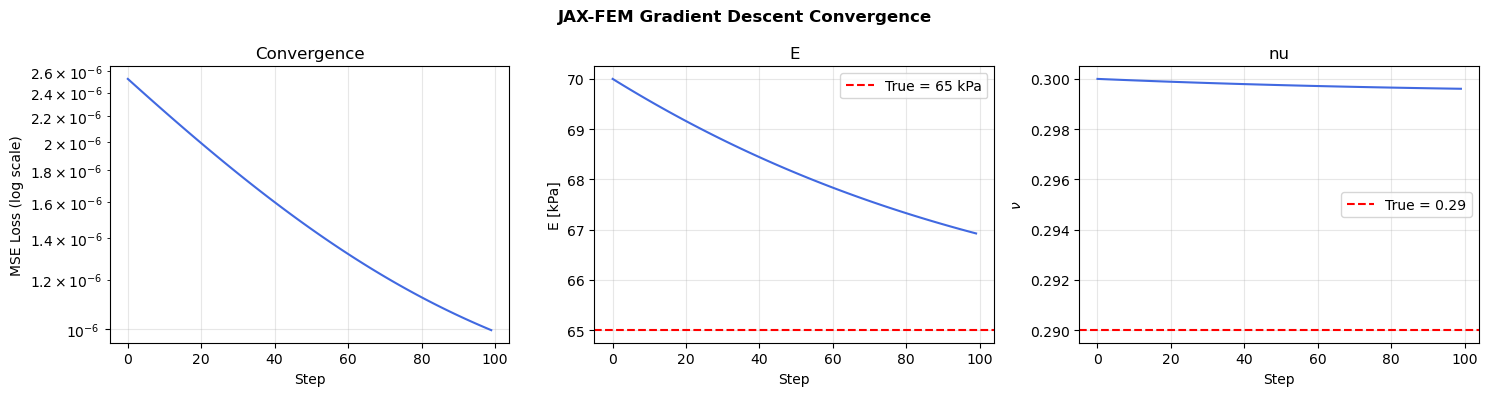

In [25]:
steps_h = [h['step']      for h in grad_history]
losses_h = [h['loss']      for h in grad_history]
E_hist   = [h['params'][0] for h in grad_history]
nu_hist  = [h['params'][1] for h in grad_history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(steps_h, losses_h, 'royalblue')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Convergence'); axes[0].grid(True, alpha=0.3)

axes[1].plot(steps_h, [e/1000 for e in E_hist], 'royalblue')
axes[1].axhline(E_true/1000, color='red', linestyle='--', label=f'True = {E_true/1000:.0f} kPa')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('E [kPa]')
axes[1].set_title("E"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(steps_h, nu_hist, 'royalblue')
axes[2].axhline(nu_true, color='red', linestyle='--', label=f'True = {nu_true}')
axes[2].set_xlabel('Step'); axes[2].set_ylabel(r'$\nu$')
axes[2].set_title("nu"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('JAX-FEM Gradient Descent Convergence', fontweight='bold')
plt.tight_layout()
plt.show()

# Generate Input/Output Samples from Simulation Model

In [26]:
num_samples = 100
q_i = Q.sample(num_samples, method='QMC_Halton')
y_i = np.array([run_fem(q[0], q[1]) for q in q_i])
df_y = pd.DataFrame(y_i, columns=y_names)
df_q = pd.DataFrame(q_i, columns=Q.param_names())

## Bayesian Update (MCMC) using directly the simulation model


In [27]:
class SimulationModel:
    def __init__(self, Q):
        self.Q = Q
    
    def predict(self, q):
        # q is a DataFrame with 1 row from DigitalTwin.loglikelihood
        E = q['E'].iloc[0]
        nu = q['nu'].iloc[0]
        return np.array(run_fem(E, nu))
    
    def grad_predict(self, q):
        return
        # q is a DataFrame with 1 row from DigitalTwin.loglikelihood
        E = q['E'].iloc[0]
        nu = q['nu'].iloc[0]
        return np.array(run_fem_grad(E, nu))

In [28]:
class SimulationModel_:
    def __init__(self, Q):
        self.Q = Q
    
    def predict(self, q):
        # q is a DataFrame with 1 row from DigitalTwin.loglikelihood
        E = q[0]
        nu = q[1]
        return run_fem(E, nu)
    
    def grad_predict(self, q):
        return
        # q is a DataFrame with 1 row from DigitalTwin.loglikelihood
        E = q['E'].iloc[0]
        nu = q['nu'].iloc[0]
        return np.array(run_fem_grad(E, nu))

MCMC creating
Burning period


100%|██████████| 20/20 [02:15<00:00,  6.78s/it]


MCMC running


100%|██████████| 50/50 [06:00<00:00,  7.21s/it]


--- 502.97288489341736 seconds ---


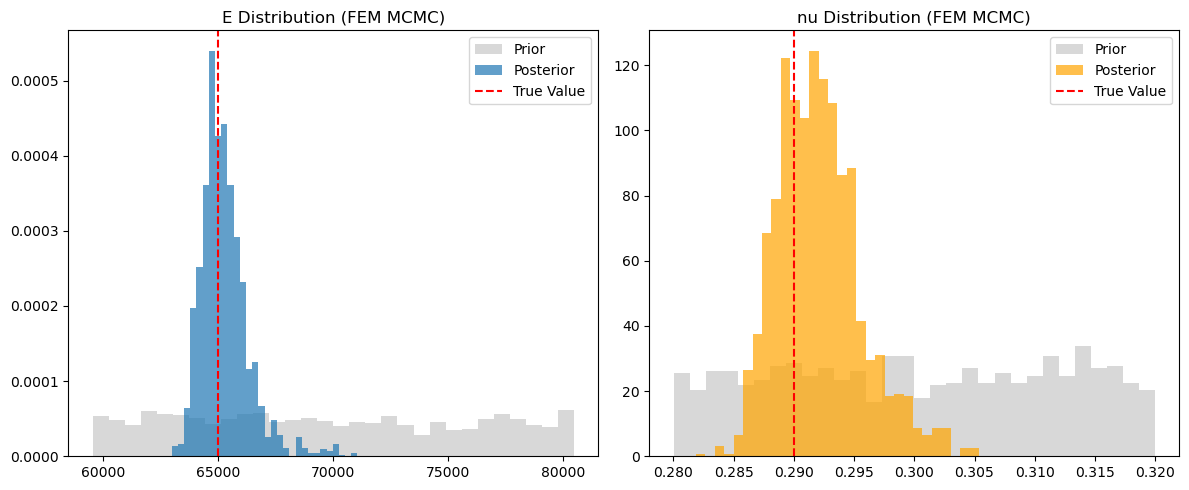

In [29]:
import digital_twinning as dt
sim_model = SimulationModel(Q)
dt = dt.DigitalTwin(sim_model, Err)
dt.update(y_m_df, nwalkers=32, nburn=20, niter=50)

samples = dt.get_posterior_samples()
prior_samples = Q.sample(1000)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(prior_samples[:, 0], bins=30, alpha=0.3, color='gray', label='Prior', density=True)
ax[0].hist(samples['E'], bins=30, alpha=0.7, label='Posterior', density=True)
ax[0].axvline(E_true, color='r', ls='--', label='True Value')
ax[0].set_title('E Distribution (FEM MCMC)')
ax[0].legend()

ax[1].hist(prior_samples[:, 1], bins=30, alpha=0.3, color='gray', label='Prior', density=True)
ax[1].hist(samples['nu'], bins=30, alpha=0.7, color='orange', label='Posterior', density=True)
ax[1].axvline(nu_true, color='r', ls='--', label='True Value')
ax[1].set_title('nu Distribution (FEM MCMC)')
ax[1].legend()

plt.tight_layout()
plt.show()

In [30]:
sim_model_ = SimulationModel_(Q)

In [31]:
def loglikelihood(q):
    return Err.logpdf((y_m - sim_model_.predict(q)).T)

def logprob(q):
    return np.squeeze(Q.logpdf(q.reshape(-1, 1)) + loglikelihood(q))

In [32]:
import emcee
import time

nwalkers = 4
nburn = 100
niter = 350

print('MCMC creating')

sampler = emcee.EnsembleSampler(nwalkers, Q.num_params(), logprob)
start_time = time.time()

print('Burning period')
q0 = Q.sample(nwalkers, method='QMC_Halton')
state = sampler.run_mcmc(q0, nburn, progress = True)
sampler.reset()

print('MCMC running')
sampler.run_mcmc(state, niter, progress = True)

print("--- %s seconds ---" % (time.time() - start_time))


q_post = sampler.get_chain(flat=True)
print(q_post.shape)



MCMC creating
Burning period


100%|██████████| 100/100 [01:35<00:00,  1.04it/s]


MCMC running


100%|██████████| 350/350 [05:49<00:00,  1.00it/s]

--- 446.8444459438324 seconds ---
(1400, 2)


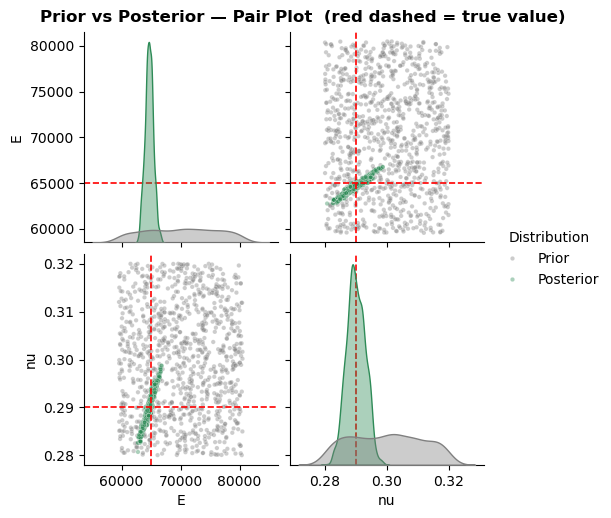

In [33]:
import seaborn as sns

# Combine prior and posterior samples into one DataFrame for pairplot
q_prior = Q.sample(1000, method='QMC_Halton')
df_prior = pd.DataFrame(q_prior, columns=Q.param_names()); df_prior['Distribution'] = 'Prior';
q_post = sampler.get_chain(flat=True)
df_post = pd.DataFrame(q_post, columns=Q.param_names()); df_post['Distribution'] = 'Posterior';

df_all = pd.concat([df_prior, df_post], ignore_index=True)

palette = {'Prior': 'gray', 'Posterior': 'seagreen'}
g = sns.pairplot(
    df_all, hue='Distribution', vars=['E', 'nu'],
    plot_kws=dict(alpha=0.4, s=10),
    diag_kws=dict(fill=True, alpha=0.4),
    palette=palette,
    diag_kind='kde', kind='scatter',
    corner=False
)

# Mark true values
for ax in g.axes.flat:
    if ax is None:
        continue
    xlabel, ylabel = ax.get_xlabel(), ax.get_ylabel()
    true_vals = {'E': E_true, 'nu': nu_true}
    if xlabel in true_vals:
        ax.axvline(true_vals[xlabel], color='red', linestyle='--', linewidth=1.2)
    if ylabel in true_vals:
        ax.axhline(true_vals[ylabel], color='red', linestyle='--', linewidth=1.2)

g.figure.suptitle('Prior vs Posterior — Pair Plot  (red dashed = true value)', y=1.02, fontweight='bold')
plt.show()

# Surrogate Based Modelling

In [34]:
y_i.shape, q_i.shape

((100, 40), (100, 2))

In [37]:
xi_k_j = Q.params2germ(q_i)
basis = dt.gPCE_model.GpcBasis(Q, p=4, I="default", full_tensor=False)

phi_k_alpha = basis.evaluate(xi_k_j)
u_alpha_i = np.matmul(np.linalg.pinv(phi_k_alpha), y_i)
u_alpha_i.shape

TypeError: JacobiPolynomials.normalized() missing 1 required positional argument: 'self'

In [ ]:
s_model = dt.SurrogateModel(Q, y_names, method='gPCE',p=4)
X_train, X_test, y_train, y_test = s_model.train_test_split(df_q, df_y, train_test_ratio=0.8)

s_model.train(X_train, y_train)

----- Training started for 'gPCE' model -----


TypeError: JacobiPolynomials.normalized() missing 1 required positional argument: 'self'

## 4. Probabilistic Inverse Modeling

Both networks are trained as direct inverse models ($y \to q$) on the 100 FEM simulations. Inference is a single forward pass — orders of magnitude faster than gradient calibration at the cost of upfront data generation.

- **CRPS:** injects $\varepsilon \sim \mathcal{N}(0,I)$ each forward pass; trained with multivariate energy score → calibrated ensemble.
- **MDN:** outputs $(K=3)$ Gaussian mixture parameters; trained by maximum log-likelihood → explicit $p(q\mid y)$.

In [40]:
crps_model = CRPSModel(Q, y_names)
crps_model.train(df_y, df_q, epochs=150, batch_size=8)

mdn_model = MDNModel(Q, y_names, num_components=3)
mdn_model.train(df_y, df_q, epochs=200, batch_size=8, lr=3e-4)

q_pred_crps = crps_model.predict(y_m.reshape(1, -1))
q_pred_mdn  = mdn_model.predict(y_m.reshape(1, -1))

print(f"CRPS: E = {q_pred_crps['E'].values[0]:.1f} Pa,  nu = {q_pred_crps['nu'].values[0]:.4f}")
print(f"MDN:  E = {q_pred_mdn['E'].values[0]:.1f} Pa,   nu = {q_pred_mdn['nu'].values[0]:.4f}")

----- Training started for 'CRPS' inverse model -----
Epoch 0: Train Loss = 0.741675, Val Loss = 0.732748
Epoch 10: Train Loss = 0.112092, Val Loss = 0.102929
Epoch 20: Train Loss = 0.022613, Val Loss = 0.026213
Epoch 30: Train Loss = 0.016348, Val Loss = 0.024733
Epoch 40: Train Loss = 0.013603, Val Loss = 0.009774
Epoch 50: Train Loss = 0.028343, Val Loss = 0.060319
Epoch 60: Train Loss = 0.020414, Val Loss = 0.016114
Epoch 70: Train Loss = 0.012722, Val Loss = 0.011348
Early stopping at epoch 75
----- Training ended for 'CRPS' inverse model -----
----- Training started for 'MDN' inverse model -----
Epoch 0: Train Loss = 1.724691, Val Loss = 1.768777
Epoch 10: Train Loss = -0.758692, Val Loss = -1.119842
Epoch 20: Train Loss = -1.617399, Val Loss = -1.610887
Epoch 30: Train Loss = -2.437902, Val Loss = -1.279041
Epoch 40: Train Loss = -2.196709, Val Loss = -1.441875
Epoch 50: Train Loss = -1.619882, Val Loss = 0.167722
Epoch 60: Train Loss = -2.457412, Val Loss = -2.527734
Epoch 70: 

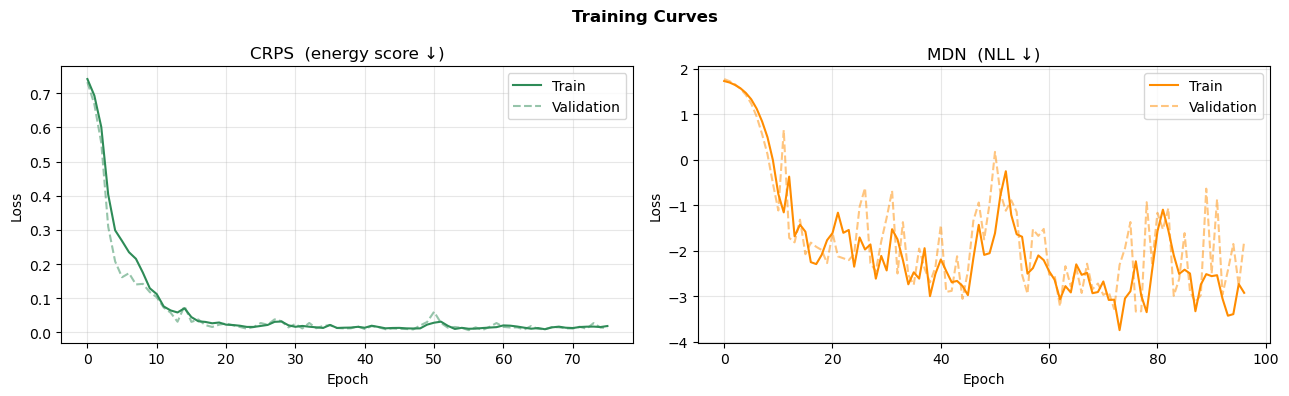

In [41]:
crps_hist = pd.DataFrame(crps_model.history)
mdn_hist  = pd.DataFrame(mdn_model.history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, hist, title, color in [
    (axes[0], crps_hist, 'CRPS  (energy score ↓)', 'seagreen'),
    (axes[1], mdn_hist,  'MDN  (NLL ↓)',           'darkorange'),
]:
    ax.plot(hist['epoch'], hist['train_loss'], color=color,         label='Train', linewidth=1.5)
    ax.plot(hist['epoch'], hist['val_loss'],   color=color, alpha=0.5,
            linestyle='--', label='Validation', linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()